<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Import-Standard-Data-Science-Packages" data-toc-modified-id="Import-Standard-Data-Science-Packages-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Import Standard Data Science Packages</a></span><ul class="toc-item"><li><span><a href="#Set-Colorblind-Friendly-Palette" data-toc-modified-id="Set-Colorblind-Friendly-Palette-1.1"><span class="toc-item-num">1.1&nbsp;&nbsp;</span>Set Colorblind-Friendly Palette</a></span></li></ul></li><li><span><a href="#Load-and-Visualise-dPCR-Data" data-toc-modified-id="Load-and-Visualise-dPCR-Data-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>Load and Visualise dPCR Data</a></span></li><li><span><a href="#Data-Analysis" data-toc-modified-id="Data-Analysis-3"><span class="toc-item-num">3&nbsp;&nbsp;</span>Data Analysis</a></span><ul class="toc-item"><li><span><a href="#Organise-Data" data-toc-modified-id="Organise-Data-3.1"><span class="toc-item-num">3.1&nbsp;&nbsp;</span>Organise Data</a></span></li><li><span><a href="#Define-ACA-Model-(Neural-Network)" data-toc-modified-id="Define-ACA-Model-(Neural-Network)-3.2"><span class="toc-item-num">3.2&nbsp;&nbsp;</span>Define ACA Model (Neural Network)</a></span></li><li><span><a href="#Train-and-Compute-Performance-(10-Fold-Cross-Val)" data-toc-modified-id="Train-and-Compute-Performance-(10-Fold-Cross-Val)-3.3"><span class="toc-item-num">3.3&nbsp;&nbsp;</span>Train and Compute Performance (10-Fold Cross Val)</a></span></li><li><span><a href="#Visualise-AMCA-Coefficients" data-toc-modified-id="Visualise-AMCA-Coefficients-3.4"><span class="toc-item-num">3.4&nbsp;&nbsp;</span>Visualise AMCA Coefficients</a></span></li><li><span><a href="#Compute-Performance-as-a-Function-of-Training-Volume" data-toc-modified-id="Compute-Performance-as-a-Function-of-Training-Volume-3.5"><span class="toc-item-num">3.5&nbsp;&nbsp;</span>Compute Performance as a Function of Training Volume</a></span></li></ul></li></ul></div>

# Import Standard Data Science Packages

In [1]:
import os
import sys
from joblib import Parallel, delayed
from tqdm.auto import tqdm
from pathlib import Path
from cycler import cycler
import pickle

import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import to_hex
from matplotlib.lines import Line2D
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedShuffleSplit, StratifiedKFold, KFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import statsmodels.api as sm
from sklearn.linear_model import LogisticRegressionCV

from scipy.stats import chi2
from scipy.stats import bartlett, ttest_ind

/vol/bitbucket/gk225/loc_ddm_venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Set Colorblind-Friendly Palette

In [ ]:
mpl.rcParams['axes.prop_cycle'] = cycler(color=[to_hex(i) for i in [
    (0.00, 0.45, 0.70),  # 1. Deep Blue (High contrast dark anchor)
    (0.90, 0.60, 0.00),  # 2. Orange (Distinct from yellow by saturation)
    (0.35, 0.70, 0.90),  # 3. Sky Blue (Lighter blue)
    (0.00, 0.60, 0.50),  # 4. Teal / Bluish Green (Heavy blue mix, safe for red-green CVD)
    (0.95, 0.90, 0.25),  # 5. Bright Yellow (Maximum luminance anchor)
    (0.80, 0.40, 0.70),  # 6. Pink / Magenta (Acts as a safe substitute for red)
    (0.20, 0.13, 0.53),  # 7. Indigo / Dark Purple (Distinct from Deep Blue by hue)
    (0.87, 0.80, 0.47),  # 8. Sand / Pale Gold (Muted yellow-brown)
    (0.27, 0.67, 0.60),  # 9. Mint / Seafoam (Lighter, desaturated teal)
    (0.65, 0.65, 0.65)   # 10. Medium Grey (Neutral baseline)
]])

# Load and Visualise dPCR Data

In [ ]:
# import chip_utilities as utils

# sys.path.insert(0, '..')
# import sigmoid_fitting as sp

# def _process_single_row(y, X):
#     return sp.extract_kinetic_parameters_original(X, y)

# def extract_kinetic_features(df, n_jobs=-1):
#     cycle_cols = df.filter(like="Cycle").columns
#     X = [col.replace("Cycle", "") for col in cycle_cols]
    
#     y_values_array = df[cycle_cols].values
    
#     features = Parallel(n_jobs=n_jobs)(
#         delayed(_process_single_row)(y, X) for y in y_values_array
#     )
    
#     return pd.DataFrame(features)

# def plot_single_curve(row):
#     plt.plot(row.filter(like="Cycle").values.T)
#     plt.show()

## MSC Outlier Detection

-----

In [4]:
exp_folder = "../../../LOC_DDM_dataset"
exp_path = Path(exp_folder, "D20250808_E00_C00_F4500KHz_U_Sample_7")
sigmoid_data_path = f'{exp_path}/normalised_ori_ac_df.csv'

result_path = exp_path / 'processed_chip_data.csv'
chip_data = pd.read_csv(result_path, index_col="Unnamed: 0")

In [5]:
y_lim_min, y_lim_max = chip_data.filter(like="Cycle").values.min(), chip_data.filter(like="Cycle").values.max()

In [6]:
chip_data.head()

,row_min,row_max,row_range,well,Cycle71.10000000000001,Cycle74.89999999999999,Cycle78.7,Cycle82.49999999999999,Cycle86.3,Cycle90.10000000000001,...,amf_label_Send_fit_abs,mean_outlier_label_0.01,mean_outlier_label_0.015,mean_outlier_label_0.02,mean_outlier_label_0.025,mean_outlier_label_0.03,mean_outlier_label_0.035,mean_outlier_label_0.04,mean_outlier_label_0.045,mean_outlier_label_0.05
0,0.209451,0.239304,0.029854,0,0.219883,0.225581,0.221032,0.223199,0.226792,0.220374,...,1.0,-1.0,-1.0,-1.0,1.0,1.0,1.0,1.0,1.0,1.0
1,0.197048,0.227095,0.030047,0,0.219883,0.225896,0.222948,0.219505,0.218379,0.214700,...,-1.0,-1.0,-1.0,-1.0,1.0,1.0,1.0,1.0,1.0,1.0
2,0.190823,0.223456,0.032633,0,0.219883,0.215283,0.218522,0.220078,0.218136,0.211950,...,-1.0,-1.0,-1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
3,0.201863,0.221085,0.019222,0,0.219883,0.218566,0.215485,0.221085,0.219090,0.216118,...,1.0,-1.0,-1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
4,0.203428,0.228837,0.025409,0,0.219883,0.223504,0.219256,0.222212,0.222212,0.211433,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


# Data Analysis
## Organise Data

## Define ACA Model (Transformer)

In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

if torch.cuda.is_available():
    device = torch.device("cuda")
    print("Optimization: Using NVIDIA GPU (CUDA)")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Optimization: Using Apple Silicon GPU (MPS)")
else:
    device = torch.device("cpu")
    print("Hardware acceleration not found, falling back to CPU")

class SignalTransformer(nn.Module):
    def __init__(self, seq_len, num_classes, d_model=128, nhead=8, num_layers=4):
        super().__init__()
        self.input_projection = nn.Linear(1, d_model)
        self.pos_embedding = nn.Parameter(torch.randn(1, seq_len, d_model))
        
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=256, 
            dropout=0.1, batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.classifier = nn.Linear(d_model, num_classes)

    def forward(self, x):
        # x: (batch, seq_len)
        x = self.input_projection(x.unsqueeze(-1)) + self.pos_embedding
        x = self.transformer_encoder(x)
        x = x.mean(dim=1) 
        return self.classifier(x)

class ChipDataset(Dataset):
    def __init__(self, features, labels):
        self.features = torch.tensor(features, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.features)

    def __getitem__(self, idx):
        return self.features[idx], self.labels[idx]

def prepare_loaders(df, filter_col=None, batch_size=32):
    # 1. Filter Outliers if specified
    if filter_col:
        df = df[df[filter_col] == 1].copy()
    
    # 2. Extract Features and Encode Labels
    X = df.filter(like="Cycle").values
    le = LabelEncoder()
    y = le.fit_transform(df['well'])
    
    # 3. Train/Val Split
    X_train, X_val, y_train, y_val = train_test_split(
        X, y, test_size=0.15, stratify=y, random_state=42
    )
    
    train_loader = DataLoader(
        ChipDataset(X_train, y_train), 
        batch_size=batch_size, 
        shuffle=True,
        num_workers=0 # Set to 4 if running as a standalone script (.py)
    )
    
    val_loader = DataLoader(
        ChipDataset(X_val, y_val), 
        batch_size=batch_size,
        num_workers=0
    )
    
    return train_loader, val_loader, le, X.shape[1], len(le.classes_)

def train_model(model, train_loader, val_loader, epochs=50, label_smoothing=0.1, lr=0.001, weight_decay=1e-2):
    model.to(device)
    criterion = nn.CrossEntropyLoss(label_smoothing=label_smoothing)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    
    for epoch in range(epochs):
        model.train()
        for signals, labels in train_loader:
            signals, labels = signals.to(device), labels.to(device)
            
            optimizer.zero_grad(set_to_none=True)
            outputs = model(signals)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            del outputs, loss, signals, labels
            
        scheduler.step()

        if (epoch + 1) % 20 == 0:
            model.eval()
            correct, total = 0, 0
            with torch.inference_mode():
                for signals, labels in val_loader:
                    signals, labels = signals.to(device), labels.to(device)
                    outputs = model(signals)
                    correct += (outputs.argmax(1) == labels).sum().item()
                    total += labels.size(0)
            print(f"Epoch {epoch+1} | Val Acc: {correct/total:.2%}")

def predict(model, data, label_encoder):
    model.eval()
    inputs = torch.as_tensor(data, dtype=torch.float32).to(device)
    
    with torch.inference_mode():
        logits = model(inputs)
        probs = torch.softmax(logits, dim=1)
        classes = logits.argmax(dim=1).cpu().numpy()
    
    return label_encoder.inverse_transform(classes), probs.cpu().numpy()

Optimization: Using NVIDIA GPU (CUDA)


In [8]:
import gc

outlier_filters = [None] + list(chip_data.iloc[:,-14:].columns)

cycle_cols = [c for c in chip_data.columns if "Cycle" in c]
X_AC_full = chip_data[cycle_cols].values

encoder = LabelEncoder()
y_full = encoder.fit_transform(chip_data['well'])

N_SPLITS = 10
sss = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=0)

result_path = exp_path / 'outlier_free_results_transformer.pkl'

if os.path.exists(result_path):
    print(f"Loading existing results from {result_path}...")
    with open(result_path, 'rb') as f:
        outlier_free_results = pickle.load(f)
else:
    print("No existing results found. Initializing new dictionary.")
    outlier_free_results = {}

for outlier_filter in outlier_filters:
    if outlier_filter in outlier_free_results:
        print(f"Skipping {outlier_filter} (already exists in results).")
        continue

    print(f"\nTraining on {outlier_filter} data")
    
    if outlier_filter is None:
        mask = np.ones(len(chip_data), dtype=bool)
    else:
        mask = (chip_data[outlier_filter] == 1).values

    X_AC = X_AC_full[mask]
    y_true = y_full[mask]
    
    num_classes = len(np.unique(y_true))
    seq_len = X_AC.shape[1]

    y_trues_ = []
    y_preds_transformer_ = []

    splits = sss.split(X_AC, y_true)
    
    for i, (train_index, test_index) in enumerate(tqdm(splits, total=N_SPLITS)):
        X_AC_train, X_AC_test = X_AC[train_index], X_AC[test_index]
        y_train, y_test = y_true[train_index], y_true[test_index]
        
        y_trues_.append(y_test)

        # 1. Create DataLoaders for this specific fold
        train_loader = DataLoader(ChipDataset(X_AC_train, y_train), batch_size=128, shuffle=True)
        test_loader = DataLoader(ChipDataset(X_AC_test, y_test), batch_size=128, shuffle=False)

        # 2. Initialize a fresh Transformer for the fold
        model = SignalTransformer(seq_len=seq_len, num_classes=num_classes)
        
        # 3. Train the model (using test_loader as validation to track progress)
        train_model(model, train_loader, test_loader, epochs=50)

        # 4. Predict on the test fold
        model.eval()
        fold_preds = []
        with torch.inference_mode():
            for signals, _ in test_loader:
                signals = signals.to(device)
                outputs = model(signals)
                preds = outputs.argmax(dim=1).cpu().numpy()
                fold_preds.extend(preds)
                
        y_preds_transformer_.append(np.array(fold_preds))
        
        # 5. Prevent VRAM leaks on Apple Silicon between folds
        del model
        del train_loader
        del test_loader
        
        # Force Python to execute garbage collection
        gc.collect()
        
        # Empty the cache
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        elif torch.backends.mps.is_available():
            torch.mps.empty_cache()

    # Store results
    outlier_free_results[outlier_filter] = {
        "y_trues": np.concatenate(y_trues_),
        "y_preds_transformer": np.concatenate(y_preds_transformer_),
        "y_trues_": y_trues_,
        "y_preds_transformer_": y_preds_transformer_,
    }

    # Checkpoint
    with open(result_path, 'wb') as f:
        pickle.dump(outlier_free_results, f)
    print(f"Results saved to {result_path}")
    print("-" * 100)

No existing results found. Initializing new dictionary.

Training on None data


  0%|          | 0/10 [00:00<?, ?it/s]

Epoch 20 | Val Acc: 15.44%
Epoch 40 | Val Acc: 15.44%


 10%|█         | 1/10 [21:12<3:10:51, 1272.42s/it]

Epoch 20 | Val Acc: 14.44%
Epoch 40 | Val Acc: 15.44%


...

Epoch 20 | Val Acc: 15.44%
Epoch 40 | Val Acc: 15.44%


 90%|█████████ | 9/10 [1:47:13<11:55, 715.11s/it]

Epoch 20 | Val Acc: 15.44%
Epoch 40 | Val Acc: 14.61%


100%|██████████| 10/10 [1:59:08<00:00, 714.82s/it]

Results saved to ../../../LOC_DDM_dataset/D20250808_E00_C00_F4500KHz_U_Sample_7/outlier_free_results_transformer.pkl
----------------------------------------------------------------------------------------------------


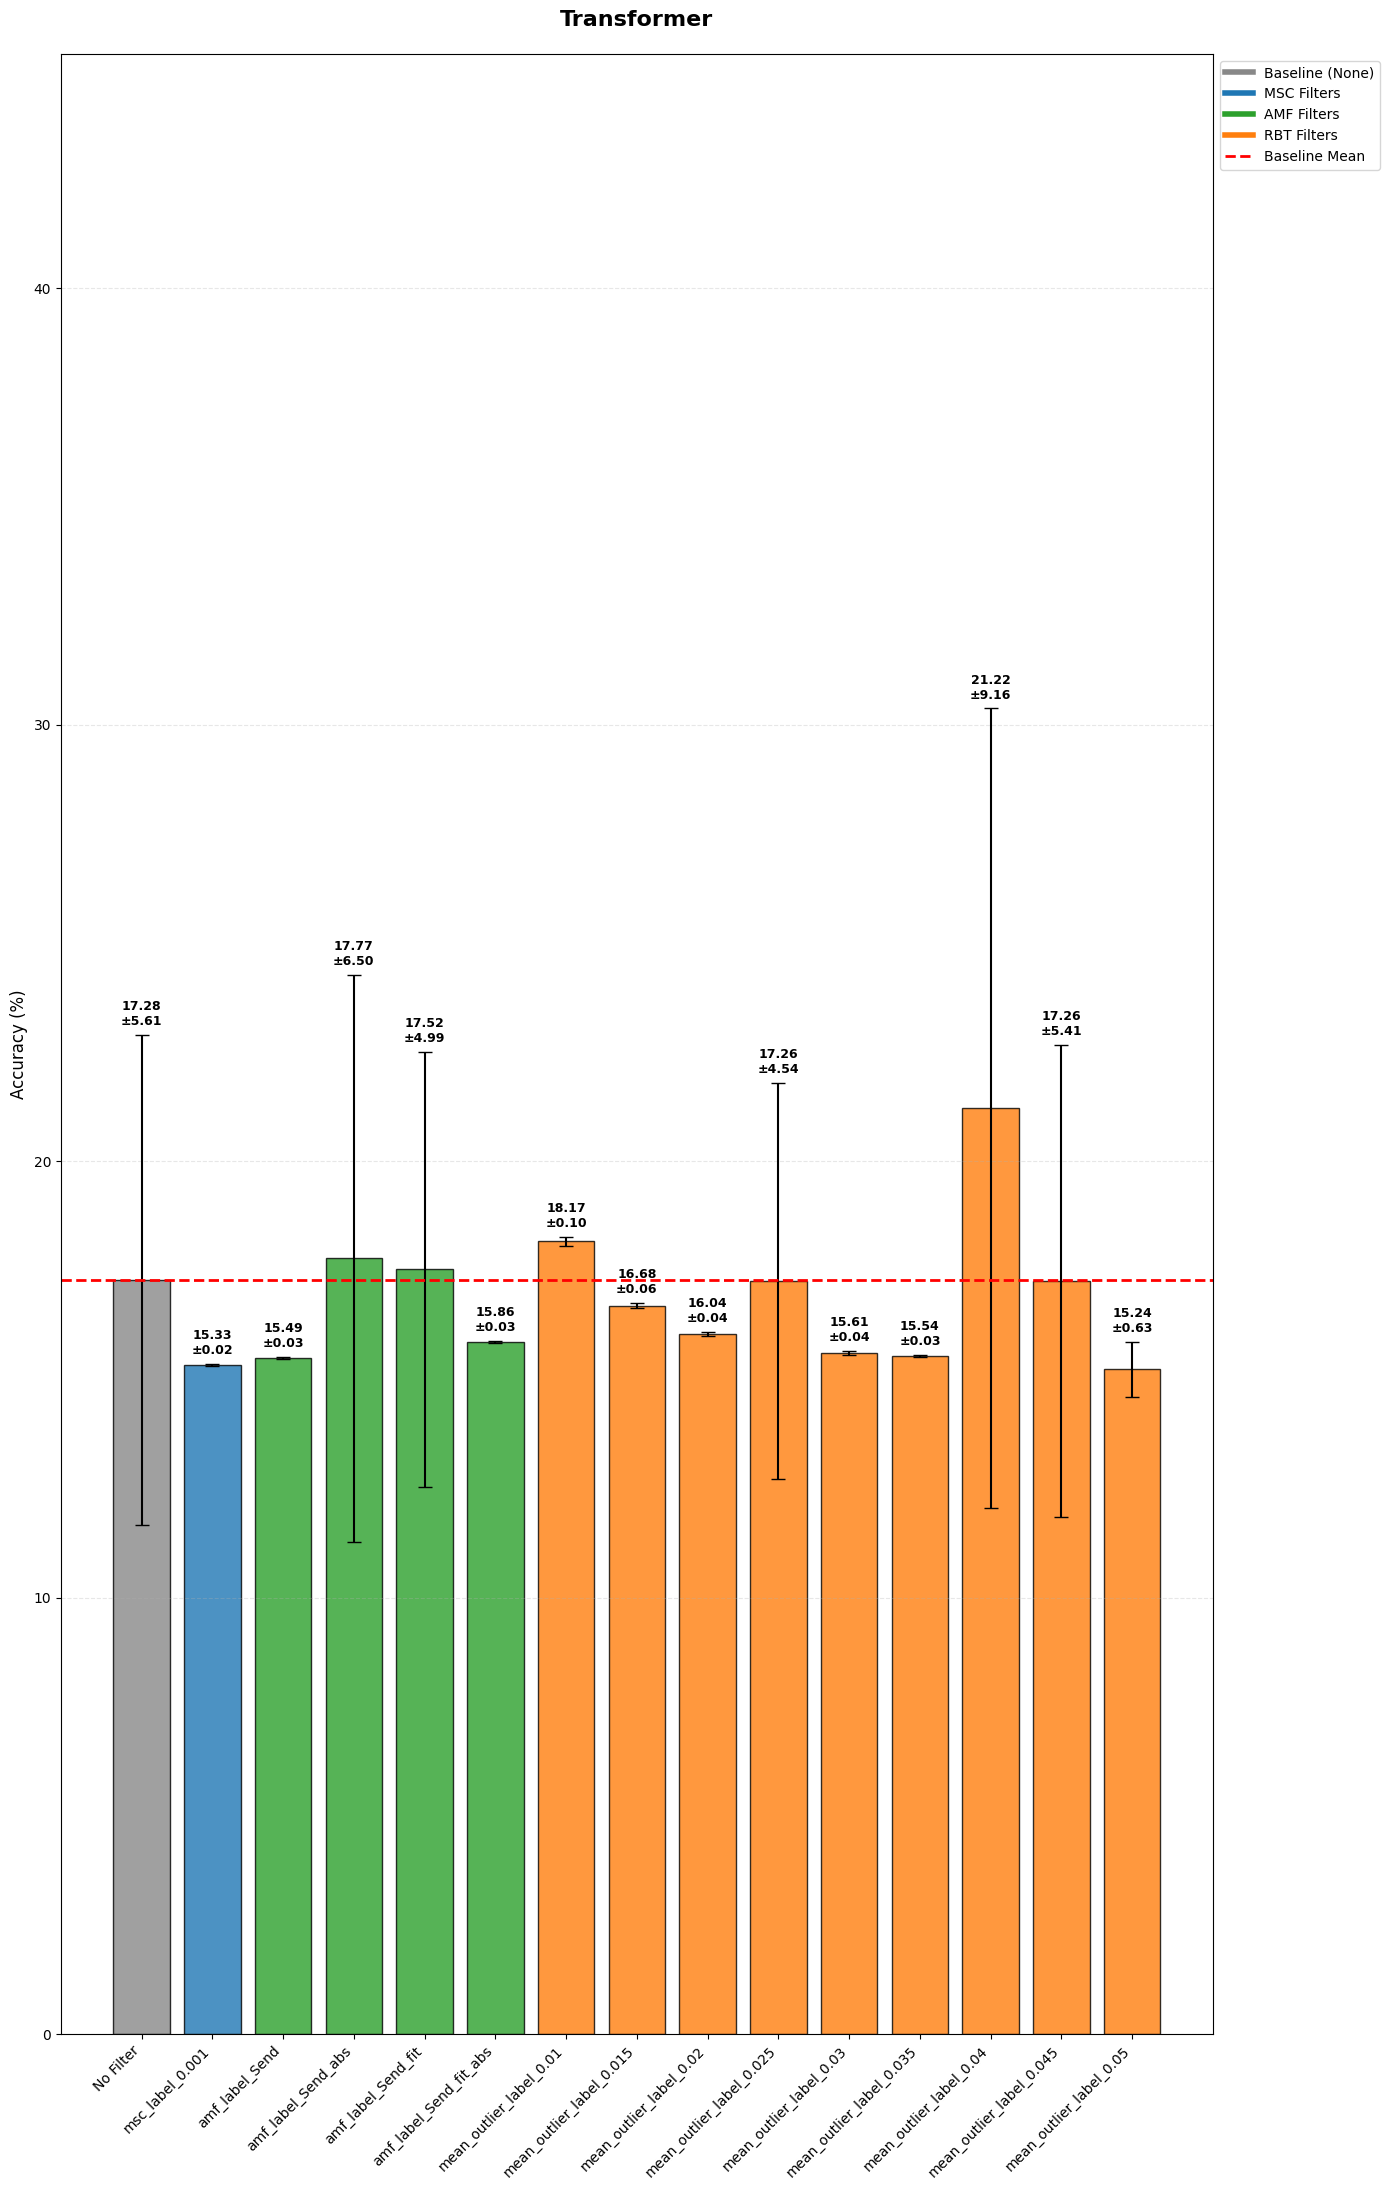

In [11]:
# 1. Setup filters and labels
base_filters = [f for f in outlier_filters if f is None or not f.startswith('mean_outlier_label_')]
mean_filters = [f for f in outlier_filters if f is not None and f.startswith('mean_outlier_label_')]
mean_filters_sorted = sorted(mean_filters, key=lambda x: float(x.split('_')[-1]))
outlier_filters = base_filters + mean_filters_sorted
filter_labels = [str(f) if f is not None else "No Filter" for f in outlier_filters]

# Define methods and the corresponding list-of-folds keys in outlier_free_results
method_info = [
    # ('Logistic Regression (FFI)', 'y_preds_FFI_'),
    # ('kNN (ACA)', 'y_preds_AC_kNN_'),
    # ('Convolutional Neural Network (ACA)', 'y_preds_AC_')
    ('Transformer', 'y_preds_transformer_')
]

# 2. Logic-based color palette
colors = []
for f in outlier_filters:
    if f is None:
        colors.append('#888888') # Grey
    elif f.startswith('msc_'):
        colors.append('#1f77b4') # Blue
    elif f.startswith('amf_'):
        colors.append('#2ca02c') # Green
    elif f.startswith('mean_'):
        colors.append('#ff7f0e') # Orange
    else:
        colors.append('#9467bd') # Purple

# 3. Data Extraction and Averaging
# We need to store both means and stds for each method
acc_means_by_method = {m_key: [] for _, m_key in method_info}
acc_stds_by_method = {m_key: [] for _, m_key in method_info}
baseline_stats = {} # To store mean and std for the 'None' filter

for f in outlier_filters:
    res = outlier_free_results[f]
    y_trues_folds = res['y_trues_'] # List of arrays per fold
    
    for _, m_key in method_info:
        y_preds_folds = res[m_key] # List of predicted arrays per fold
        
        # Calculate accuracy for each fold
        fold_accuracies = [
            accuracy_score(y_tr, y_pred) * 100 
            for y_tr, y_pred in zip(y_trues_folds, y_preds_folds)
        ]
        
        mean_val = np.mean(fold_accuracies)
        std_val = np.std(fold_accuracies)
        
        acc_means_by_method[m_key].append(mean_val)
        acc_stds_by_method[m_key].append(std_val)
        
        # Capture baseline stats for the red line
        if f is None:
            baseline_stats[m_key] = (mean_val, std_val)

# 4. Plotting
fig, axes = plt.subplots(len(method_info), 1, figsize=(14, 22))
ax = axes
(title, m_key) = method_info[0]
# for ax, (title, m_key) in zip(axes, method_info):
means = acc_means_by_method[m_key]
stds = acc_stds_by_method[m_key]
base_mean, base_std = baseline_stats[m_key]

# Create the custom labels: "mean ± std"
bar_labels = [f'{m:.2f}\n±{s:.2f}' for m, s in zip(means, stds)]

# Plot bars with error bars (yerr)
bars = ax.bar(filter_labels, means, yerr=stds, color=colors, 
                edgecolor='black', alpha=0.8, capsize=5)

# Add horizontal baseline based on 'None' mean
ax.axhline(y=base_mean, color='red', linestyle='--', linewidth=2, 
            label=f'Baseline ({base_mean:.2f}%)')

# Add the text labels on top
ax.bar_label(bars, labels=bar_labels, padding=5, fontsize=9, fontweight='bold')

# Formatting
ax.set_title(title, fontsize=16, fontweight='bold', pad=20)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_ylim(0, min(100, max(means) + max(stds)) + 15) # Dynamic height

ax.set_xticks(range(len(filter_labels)))
ax.set_xticklabels(filter_labels, rotation=45, ha='right', fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.3)

# Custom Legend
legend_elements = [
    Line2D([0], [0], color='#888888', lw=4, label='Baseline (None)'),
    Line2D([0], [0], color='#1f77b4', lw=4, label='MSC Filters'),
    Line2D([0], [0], color='#2ca02c', lw=4, label='AMF Filters'),
    Line2D([0], [0], color='#ff7f0e', lw=4, label='RBT Filters'),
    Line2D([0], [0], color='red', linestyle='--', lw=2, label='Baseline Mean')
]
ax.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.show()

In [ ]:
outlier_filters

[None,
 'msc_label_0.001',
 'amf_label_Send',
 'amf_label_Send_abs',
 'amf_label_Send_fit',
 'amf_label_Send_fit_abs',
 'mean_outlier_label_0.01',
 'mean_outlier_label_0.015',
 'mean_outlier_label_0.02',
 'mean_outlier_label_0.025',
 'mean_outlier_label_0.03',
 'mean_outlier_label_0.035',
 'mean_outlier_label_0.04',
 'mean_outlier_label_0.045',
 'mean_outlier_label_0.05']

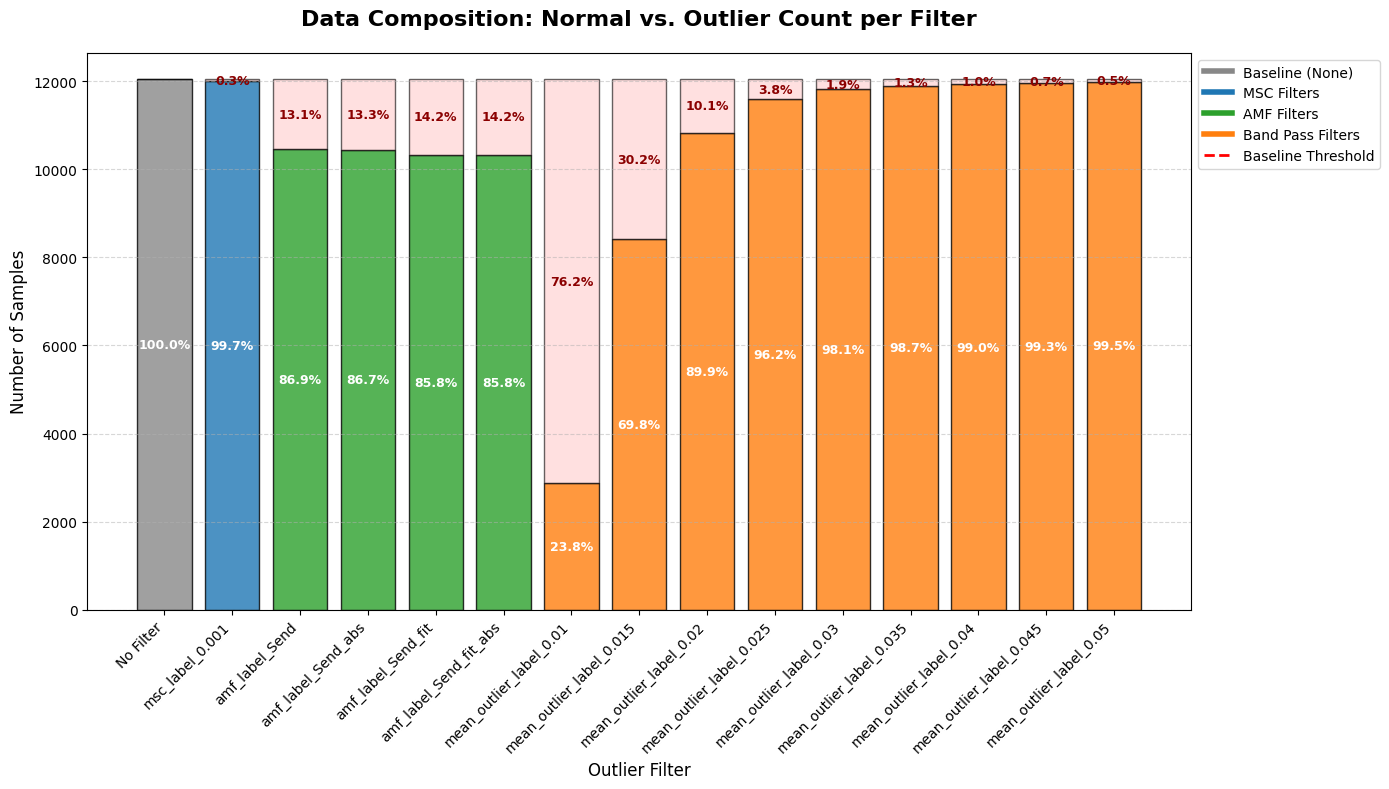

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Setup Data and Colors
base_filters = [f for f in outlier_filters if f is None or not f.startswith('mean_outlier_label_')]
mean_filters = [f for f in outlier_filters if f is not None and f.startswith('mean_outlier_label_')]
mean_filters_sorted = sorted(mean_filters, key=lambda x: float(x.split('_')[-1]))
outlier_filters = base_filters + mean_filters_sorted
filter_labels = [str(f) if f is not None else "No Filter" for f in outlier_filters]

n_normals = []
n_outliers = []

total_count = len(chip_data)

for f in outlier_filters:
    # Logic to get counts
    if f is None:
        mask = np.ones(total_count, dtype=bool)
    else:
        mask = (chip_data[f] == 1).values

    n_normal = np.sum(mask)
    n_outlier = total_count - n_normal
    
    n_normals.append(n_normal)
    n_outliers.append(n_outlier)

# 2. Plotting
fig, ax = plt.subplots(figsize=(14, 8))

# Bottom stack: Normal data
# Using your categorical colors here
bars_normal = ax.bar(filter_labels, n_normals, color=colors, 
                     edgecolor='black', alpha=0.8, label='Normal')

# Top stack: Outlier data
# Using a consistent light red/grey to show discarded volume
bars_outlier = ax.bar(filter_labels, n_outliers, bottom=n_normals, 
                      color='#ffcccc', edgecolor='black', alpha=0.6, label='Outlier')

# 3. Add percentage labels on the stacks
for i in range(len(filter_labels)):
    # Label for Normal portion
    if n_normals[i] > 0:
        ax.text(i, n_normals[i]/2, f'{(n_normals[i]/total_count)*100:.1f}%', 
                ha='center', va='center', color='white', fontweight='bold', fontsize=9)
    
    # Label for Outlier portion
    if n_outliers[i] > 0:
        ax.text(i, n_normals[i] + (n_outliers[i]/2), f'{(n_outliers[i]/total_count)*100:.1f}%', 
                ha='center', va='center', color='darkred', fontweight='bold', fontsize=9)

# 4. Formatting
ax.set_title("Data Composition: Normal vs. Outlier Count per Filter", fontsize=16, fontweight='bold', pad=20)
ax.set_ylabel("Number of Samples", fontsize=12)
ax.set_xlabel("Outlier Filter", fontsize=12)

ax.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1, 1))

plt.ylim(0, mask.shape[0]*1.05)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()